In [4]:
import re
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import plotly.graph_objs as go

In [6]:
# Caminho completo do arquivo
arq = r"C:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\DATATHON\basededadospm.xlsx"

# Leitura do XLSX
dados = pd.read_excel(
    arq,
    skiprows=3,        # pula linhas iniciais
    skipfooter=12,     # ignora linhas finais
    decimal=',',       # separador decimal
    thousands='.',     # separador de milhar
    engine='openpyxl'  
)


In [9]:
pd.set_option('display.max_columns', None)
df = pd.read_excel(r"C:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\DATATHON\basededadospm.xlsx")
df.head(2)

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [10]:
excel_file = pd.ExcelFile(r"C:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\DATATHON\basededadospm.xlsx")
sheets_dict = pd.read_excel(excel_file, sheet_name=None)
print("Sheets found:", list(sheets_dict.keys()))
df_PEDE_2022 = sheets_dict['PEDE2022']
df_PEDE_2023 = sheets_dict['PEDE2023']
df_PEDE_2024 = sheets_dict['PEDE2024']

Sheets found: ['PEDE2022', 'PEDE2023', 'PEDE2024']


In [11]:
#Analisando as colunas de cada dt
print("Columns of df_PEDE_2022:")
print(df_PEDE_2022.columns.tolist())
print("\nColumns of df_PEDE_2023:")
print(df_PEDE_2023.columns.tolist())
print("\nColumns of df_PEDE_2024:")
print(df_PEDE_2024.columns.tolist())

Columns of df_PEDE_2022:
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

Columns of df_PEDE_2023:
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem

In [12]:
#Acrescentando a coluna "Ano" em cada dataframe para marcar o ano de cada df que será empilhado e teraá suas colunas que registram os anos modificadas e padronizadas
df_PEDE_2022['Ano'] = 2022
df_PEDE_2023['Ano'] = 2023
df_PEDE_2024['Ano'] = 2024

print("Coluna 'Ano' adicionada aos DataFrames df_PEDE_2022, df_PEDE_2023 e df_PEDE_2024.")

Coluna 'Ano' adicionada aos DataFrames df_PEDE_2022, df_PEDE_2023 e df_PEDE_2024.


In [13]:
# Renomeando colunas para padronizar 'Pedra', 'INDE', 'Nome Anonimizado' e 'Defasagem'

df_PEDE_2022 = df_PEDE_2022.rename(columns={'Pedra 22': 'Pedra', 'INDE 22': 'INDE'})
df_PEDE_2023 = df_PEDE_2023.rename(columns={'Pedra 2023': 'Pedra', 'INDE 2023': 'INDE'})
df_PEDE_2024 = df_PEDE_2024.rename(columns={'Pedra 2024': 'Pedra', 'INDE 2024': 'INDE'})

# Renomear 'Nome' para 'Nome Anonimizado' apenas em df_PEDE_2022
df_PEDE_2022 = df_PEDE_2022.rename(columns={'Nome': 'Nome Anonimizado'})

# Renomear 'Defas' para 'Defasagem' apenas em df_PEDE_2022
df_PEDE_2022 = df_PEDE_2022.rename(columns={'Defas': 'Defasagem'})

# Adicionar a coluna 'IPP' em df_PEDE_2022 e preencher com "Não informado"
df_PEDE_2022['IPP'] = "Não informado"

# Listas de colunas a serem removidas de cada DataFrame após a padronização
# O objetivo é eliminar as colunas antigas (ano-específicas) de 'Pedra' e 'INDE'
# e outras colunas que não são comuns após a padronização.


In [14]:
#Identificando quais colunas os dfs tem em comum para poder empilhar os dados

columns_2022 = set(df_PEDE_2022.columns)
columns_2023 = set(df_PEDE_2023.columns)
columns_2024 = set(df_PEDE_2024.columns)

common_columns = list(columns_2022.intersection(columns_2023, columns_2024))

print("As colunas que são iguais em todos os DataFrames de 2022, 2023 e 2024 são:")
print(common_columns)

As colunas que são iguais em todos os DataFrames de 2022, 2023 e 2024 são:
['IAA', 'Rec Av1', 'IPS', 'IEG', 'IPP', 'IDA', 'Pedra 20', 'IPV', 'Pedra', 'Avaliador3', 'IAN', 'Rec Psicologia', 'Turma', 'Atingiu PV', 'Gênero', 'Indicado', 'INDE', 'Instituição de ensino', 'Avaliador2', 'Fase', 'Pedra 21', 'Rec Av2', 'Ano ingresso', 'Ano', 'Avaliador1', 'Cf', 'Nº Av', 'Ct', 'Destaque IEG', 'Destaque IPV', 'Nome Anonimizado', 'Cg', 'RA', 'Destaque IDA', 'Avaliador4', 'Defasagem']


In [15]:
# Colunas a serem consideradas para concatenação (lista fornecida pelo usuário)
colunas_empilhado_indicadores = ['Turma', 'IAN', 'IPS', 'IDA', 'IAA','IPP', 'INDE','Ano ingresso', 'Nome Anonimizado', 'Cg', 'Gênero', 'Fase', 'RA', 'Instituição de ensino', 'Atingiu PV', 'Pedra', 'Cf', 'Indicado', 'Destaque IPV', 'Ct', 'Rec Psicologia', 'IPV', 'Destaque IEG', 'Ano', 'IEG', 'Destaque IDA','Defasagem']

# Removendo colunas duplicadas de cada DataFrame antes de filtrar
df_PEDE_2022 = df_PEDE_2022.loc[:,~df_PEDE_2022.columns.duplicated()]
df_PEDE_2023 = df_PEDE_2023.loc[:,~df_PEDE_2023.columns.duplicated()]
df_PEDE_2024 = df_PEDE_2024.loc[:,~df_PEDE_2024.columns.duplicated()]

# Filtrando cada DataFrame para conter apenas as colunas solicitadas
df_PEDE_2022_filtrado_indicadores = df_PEDE_2022[colunas_empilhado_indicadores]
df_PEDE_2023_filtrado_indicadores = df_PEDE_2023[colunas_empilhado_indicadores]
df_PEDE_2024_filtrado_indicadores = df_PEDE_2024[colunas_empilhado_indicadores]

# Concatenando os DataFrames filtrados
df_empilhado_indicadores = pd.concat([df_PEDE_2022_filtrado_indicadores, df_PEDE_2023_filtrado_indicadores, df_PEDE_2024_filtrado_indicadores], ignore_index=True)

print("DataFrames empilhados com sucesso, contendo apenas as colunas solicitadas.")
print(f"O DataFrame resultante possui {df_empilhado_indicadores.shape[0]} linhas e {df_empilhado_indicadores.shape[1]} colunas.")
display(df_empilhado_indicadores.tail(1))

DataFrames empilhados com sucesso, contendo apenas as colunas solicitadas.
O DataFrame resultante possui 3030 linhas e 27 colunas.


,Turma,IAN,IPS,IDA,IAA,IPP,INDE,Ano ingresso,Nome Anonimizado,Cg,Gênero,Fase,RA,Instituição de ensino,Atingiu PV,Pedra,Cf,Indicado,Destaque IPV,Ct,Rec Psicologia,IPV,Destaque IEG,Ano,IEG,Destaque IDA,Defasagem
3029,9,10.0,NaN,NaN,NaN,NaN,INCLUIR,2021,Aluno-1661,NaN,Feminino,9,RA-1661,Bolsista Universitário *Formado (a),NaN,INCLUIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,0.0,NaN,1


In [16]:
#Identificando quantidade de valores nulos em cada coluna para definir se faz sentido seguir com todos os indicadores

null_counts = df_empilhado_indicadores.isnull().sum()
null_percentages = (df_empilhado_indicadores.isnull().sum() / len(df_empilhado_indicadores)) * 100

null_analysis = pd.DataFrame({
    'Total Nulos': null_counts,
    'Percentual Nulos': null_percentages
})

null_analysis = null_analysis.sort_values(by='Percentual Nulos', ascending=False)

print("Análise de Valores Nulos no df_empilhado_indicadores:")
print(null_analysis[null_analysis['Total Nulos'] > 0])

Análise de Valores Nulos no df_empilhado_indicadores:
                       Total Nulos  Percentual Nulos
Cg                            2170         71.617162
Destaque IPV                  2170         71.617162
Atingiu PV                    2170         71.617162
Ct                            2170         71.617162
Rec Psicologia                2170         71.617162
Destaque IEG                  2170         71.617162
Destaque IDA                  2170         71.617162
Cf                            2170         71.617162
Indicado                      2170         71.617162
IDA                            178          5.874587
IPP                            178          5.874587
IPV                            178          5.874587
IPS                            171          5.643564
IAA                            165          5.445545
Pedra                          147          4.851485
INDE                           147          4.851485
IEG                             76          2

In [17]:
# Definindo as colunas solicitadas para o df_indicadores_finais
#Esses Indicadores foram definidos pois além de serem solicitados nas análises do Datathon, são os únicos que possuem poucos dados nulos na base
selected_cols_for_final_df = ['IDA', 'IPV', 'IPP', 'IPS', 'IAA', 'INDE', 'IEG','IAN', 'Defasagem']

# Criando o novo DataFrame df_indicadores_finais com as colunas selecionadas
df_indicadores_finais = df_empilhado_indicadores[selected_cols_for_final_df].copy()

# Removendo todas as linhas que contenham valores nulos em qualquer uma das colunas selecionadas
df_indicadores_finais.dropna(inplace=True)

print("DataFrame 'df_indicadores_finais' criado e valores nulos removidos com sucesso.")
print(f"O DataFrame resultante possui {df_indicadores_finais.shape[0]} linhas e {df_indicadores_finais.shape[1]} colunas.")
display(df_indicadores_finais.head())

# Verificando novamente a existência de valores nulos no novo DataFrame
print("\nVerificação final de valores nulos no df_indicadores_finais:")
print(df_indicadores_finais.isnull().sum())
print(df_indicadores_finais.info())

DataFrame 'df_indicadores_finais' criado e valores nulos removidos com sucesso.
O DataFrame resultante possui 2845 linhas e 9 colunas.


,IDA,IPV,IPP,IPS,IAA,INDE,IEG,IAN,Defasagem
0,4.0,7.278,Não informado,5.6,8.3,5.783,4.1,5.0,-1
1,6.8,6.778,Não informado,6.3,8.8,7.055,5.2,10.0,0
2,5.6,7.556,Não informado,5.6,0.0,6.591,7.9,10.0,0
3,5.0,5.278,Não informado,5.6,8.8,5.951,4.5,10.0,0
4,5.2,7.389,Não informado,5.6,7.9,7.427,8.6,10.0,0



Verificação final de valores nulos no df_indicadores_finais:
IDA          0
IPV          0
IPP          0
IPS          0
IAA          0
INDE         0
IEG          0
IAN          0
Defasagem    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IDA        2845 non-null   float64
 1   IPV        2845 non-null   float64
 2   IPP        2845 non-null   object 
 3   IPS        2845 non-null   float64
 4   IAA        2845 non-null   float64
 5   INDE       2845 non-null   object 
 6   IEG        2845 non-null   float64
 7   IAN        2845 non-null   float64
 8   Defasagem  2845 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 222.3+ KB
None


In [18]:
#Verificando se as linhas que estavam com os dados nulos que foram tirados, também removeu o que tinha como 'INCLUIR' na coluna 'INDE'
#Foi verificado que a quantidade de linhas sem 'INCLUIR' no 'INDE' é o mesmo número que sem os nulos, mostrando que podemos usar o df_indicadores_finais
df_indicadores_finais_INDE = df_indicadores_finais[df_indicadores_finais['INDE'] != 'INCLUIR']
df_indicadores_finais_INDE['INDE'].unique()
df_indicadores_finais_INDE.info()

<class 'pandas.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IDA        2845 non-null   float64
 1   IPV        2845 non-null   float64
 2   IPP        2845 non-null   object 
 3   IPS        2845 non-null   float64
 4   IAA        2845 non-null   float64
 5   INDE       2845 non-null   object 
 6   IEG        2845 non-null   float64
 7   IAN        2845 non-null   float64
 8   Defasagem  2845 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 222.3+ KB


Próximos passos:
Matriz de correlação
Gráficos de barras, dispersão e violino
Fazer análise dos indicadores e coletar insigts para a próxima etapa
Criar os dataframes finais

In [19]:
#IPP e INDE estão em formato de objeto e serão convertidos em float

df_indicadores_finais['IPP'] = pd.to_numeric(df_indicadores_finais['IPP'], errors='coerce')
mean_ipp = df_indicadores_finais['IPP'].mean()
df_indicadores_finais['IPP'].fillna(mean_ipp, inplace=True)

df_indicadores_finais['INDE'] = pd.to_numeric(df_indicadores_finais['INDE'], errors='coerce')
mean_inde = df_indicadores_finais['INDE'].mean()
df_indicadores_finais['INDE'].fillna(mean_inde, inplace=True)

print(df_indicadores_finais[['IPP', 'INDE']].info())

<class 'pandas.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IPP     1985 non-null   float64
 1   INDE    2845 non-null   float64
dtypes: float64(2)
memory usage: 66.7 KB
None


C:\Users\NicollyPaivaHeinzl\AppData\Local\Temp\ipykernel_30392\1416862778.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_indicadores_finais['IPP'].fillna(mean_ipp, inplace=True)
C:\Users\NicollyPaivaHeinzl\AppData\Local\Temp\ipykernel_30392\1416862778.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame

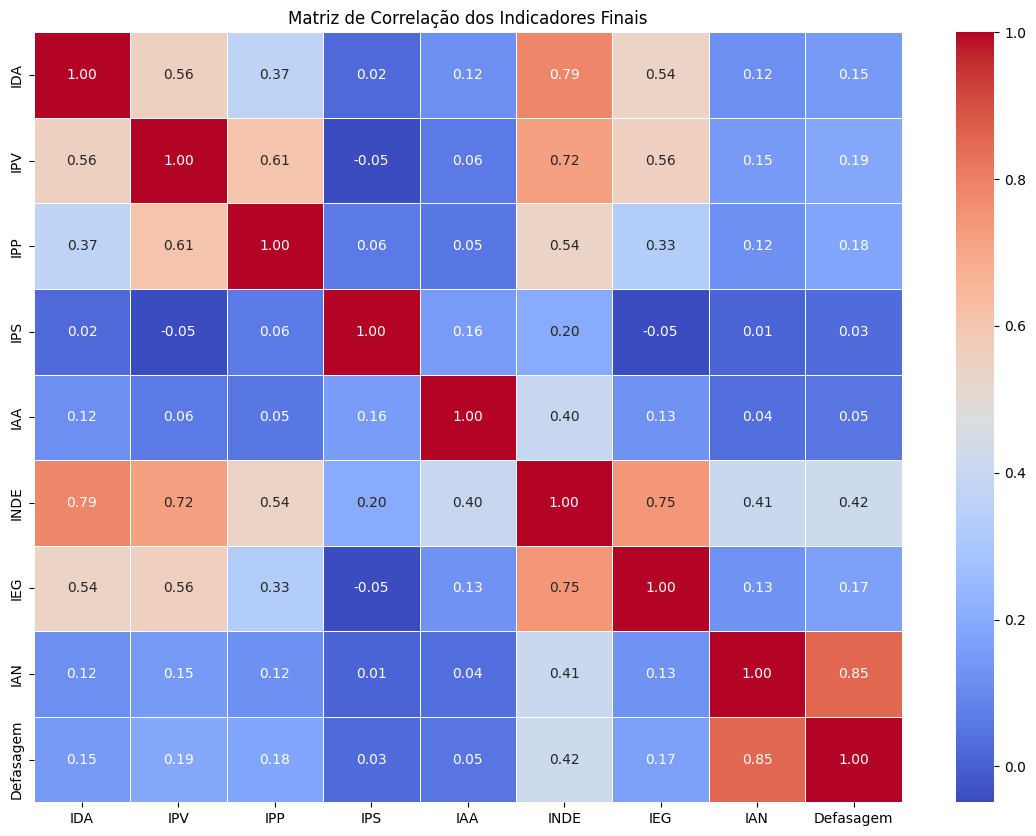

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

#Criando matriz de correlação entre os principais indicadores, observando o target que é a Defasagem
correlation_matrix = df_indicadores_finais.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação dos Indicadores Finais')
plt.show()

Análise da Matriz de correlação
Aqui identifimos que os Indicadores que mais possuem uma correlação forte em relação a target alvo (Defasagem) são o "IAN" e o "INDE"

In [22]:
#Criando defasagem binária para análise gráfica de distribuição
#Tudo que é menor ou igual do que -1 será considerado como defasado, e tudo que for maior do que -1 será considerado não defasado
df_indicadores_finais['Defasagem_bin'] = df_indicadores_finais['Defasagem'].apply(lambda x: 1 if x <= -1 else 0)
print("Coluna 'Defasagem_bin' criada com sucesso.")
print(df_indicadores_finais[['Defasagem', 'Defasagem_bin']].head())

Coluna 'Defasagem_bin' criada com sucesso.
   Defasagem  Defasagem_bin
0         -1              1
1          0              0
2          0              0
3          0              0
4          0              0


Criando visualizações gráficas para análise mais detalhada dos indicadores

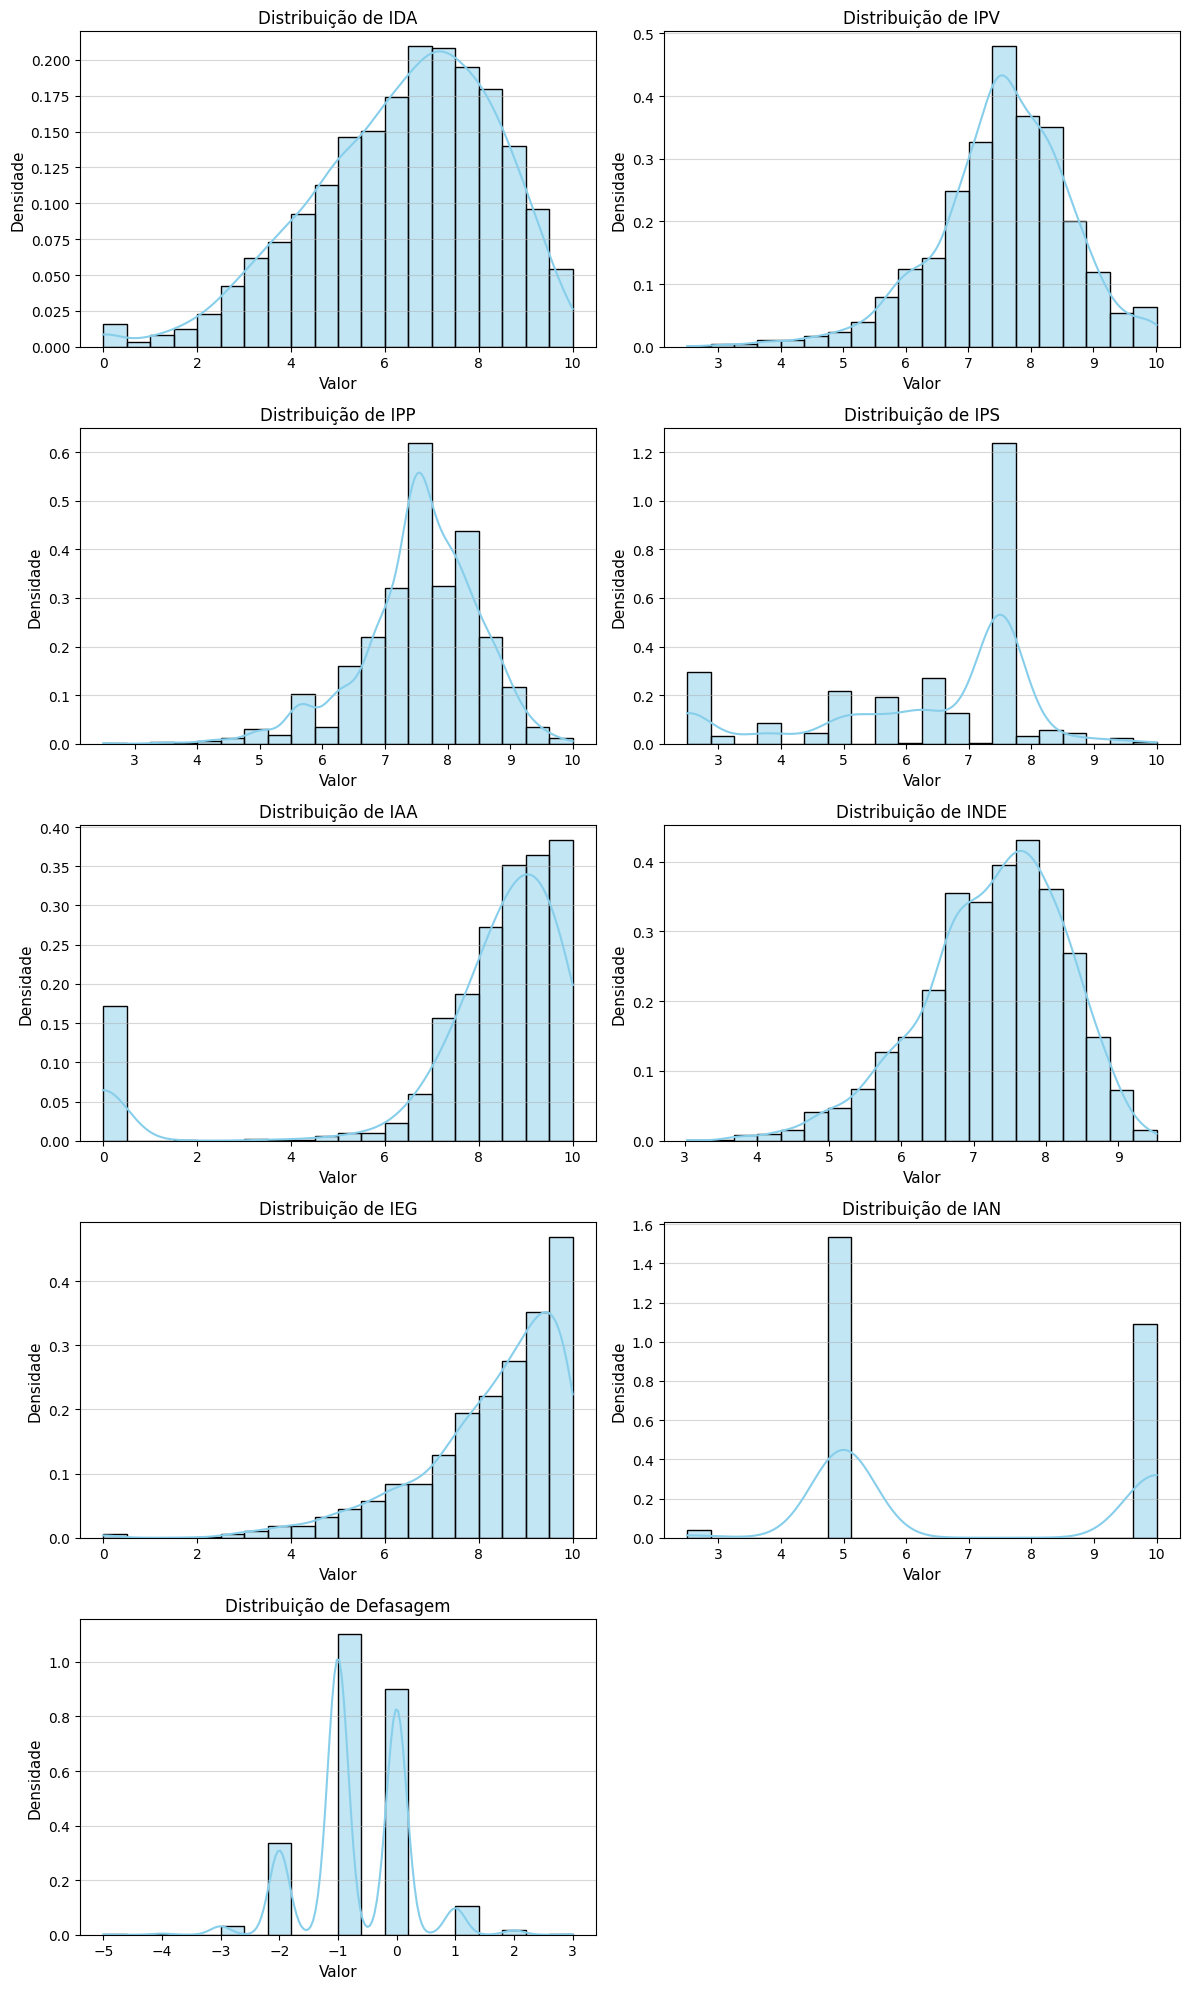

Histogramas e gráficos de densidade para todas as colunas numéricas foram gerados com sucesso, organizados em duas colunas.


In [23]:
# Identificar colunas numéricas (excluindo 'Defasagem_bin')
numeric_cols = df_indicadores_finais.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Defasagem_bin')

# Definir o número de colunas para o layout dos gráficos
n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols # Calcula o número de linhas necessário

plt.figure(figsize=(12, n_rows * 4)) # Ajusta o tamanho da figura com base no número de linhas

# Iterar sobre cada coluna numérica para plotar histograma e KDE
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Cria um subplot na posição correta
    sns.histplot(df_indicadores_finais[col], kde=True, stat='density', bins=20, color='skyblue')
    plt.title(f'Distribuição de {col}', fontsize=12)
    plt.xlabel('Valor', fontsize=11)
    plt.ylabel('Densidade', fontsize=11)
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()
print("Histogramas e gráficos de densidade para todas as colunas numéricas foram gerados com sucesso, organizados em duas colunas.")

Análise Gráfica:
IAN (Índice de Análise Numérica): Este é o indicador mais impactante! Alunos não defasados (0) têm IAN predominantemente 10, enquanto alunos defasados (1) têm IAN concentrado em 5. Isso mostra uma clara distinção.
INDE (Índice de Desenvolvimento Estudantil): Alunos não defasados (0) geralmente possuem um INDE ligeiramente maior (pico em 7.5-8) que os alunos defasados (1) (pico em 6.5-7.5).
Defasagem (original): A maioria dos alunos não tem defasagem (0), com picos menores em níveis de defasagem como -1 e -2.
Outros Indicadores (IDA, IPV, IPP, IPS, IAA, IEG): A distribuição desses indicadores é muito similar entre alunos defasados e não defasados, o que reforça o que foi analisado na matriz de correlação, que eles têm menos poder discriminatório individualmente para identificar a defasagem.

Relação de Indicadores com a Defasagem Binária
Criar box plots ou violin plots para cada indicador numérico versus a coluna Defasagem_bin. Isso mostrará como a distribuição de cada indicador difere entre os grupos de defasagem (-1 e 0), ajudando a identificar features importantes para prever a defasagem.

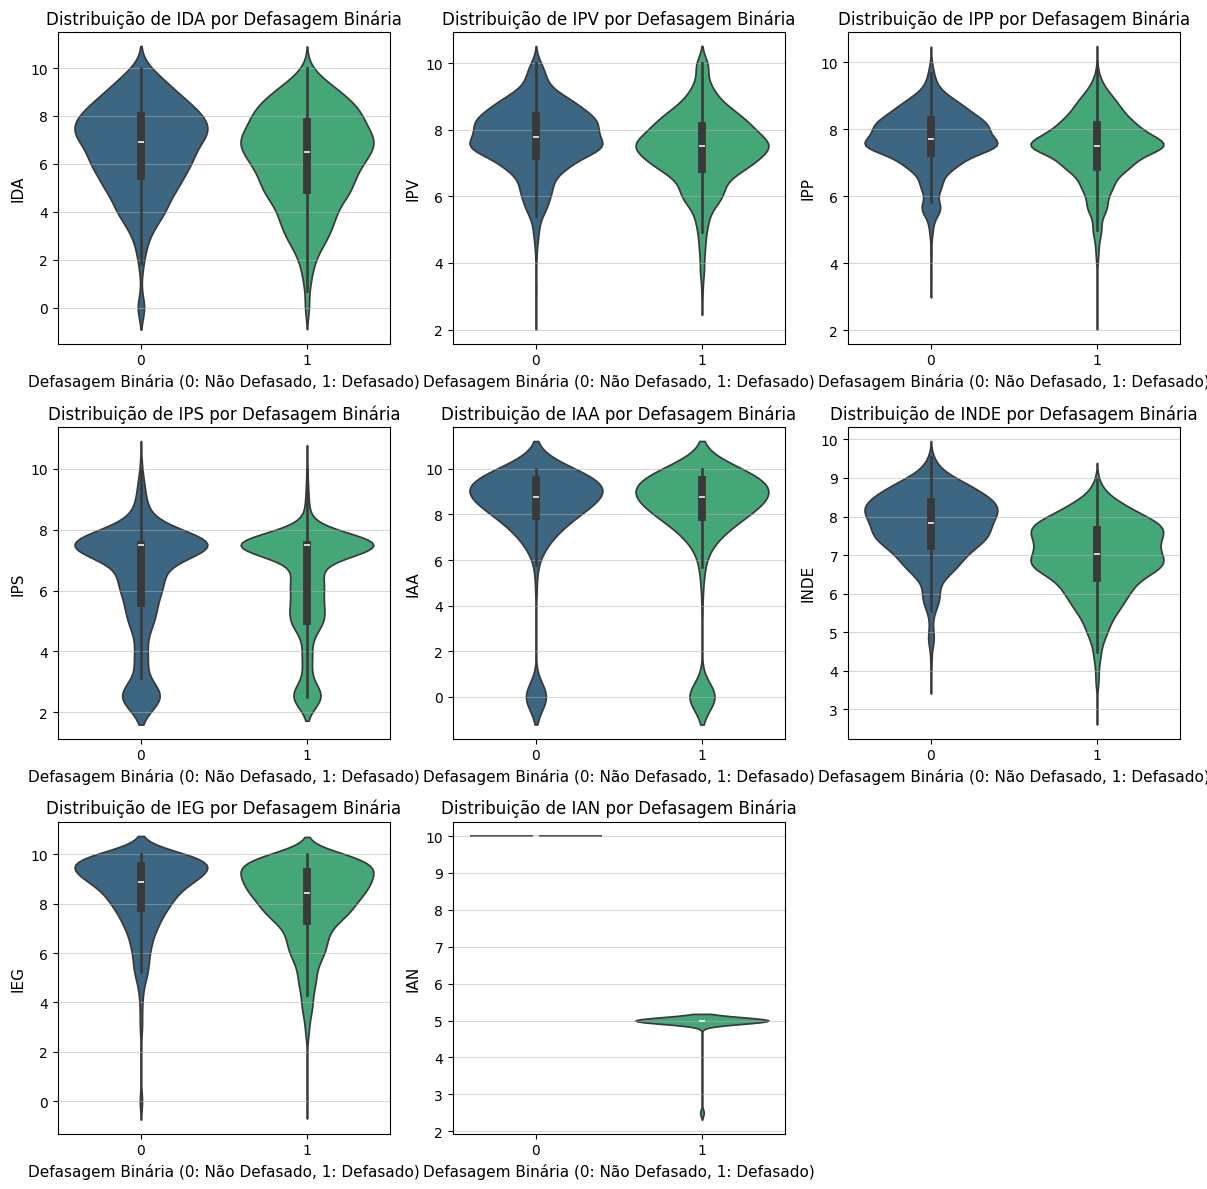

Violin plots para a relação entre indicadores numéricos e 'Defasagem_bin' foram gerados com sucesso, organizados em duas colunas.


In [24]:
# Identificar colunas numéricas (excluindo 'Defasagem_bin')
numeric_cols_for_violin = df_indicadores_finais.select_dtypes(include=np.number).columns.tolist()
numeric_cols_for_violin.remove('Defasagem_bin')
numeric_cols_for_violin.remove('Defasagem')
# Definir o número de colunas para o layout dos gráficos
n_cols = 3
n_rows = (len(numeric_cols_for_violin) + n_cols - 1) // n_cols # Calcula o número de linhas necessário

plt.figure(figsize=(12, n_rows * 4)) # Ajusta o tamanho da figura com base no número de linhas

# Iterar sobre cada coluna numérica para criar violin plots
for i, col in enumerate(numeric_cols_for_violin):
    plt.subplot(n_rows, n_cols, i + 1) # Cria um subplot na posição correta
    sns.violinplot(x='Defasagem_bin', y=col, data=df_indicadores_finais, hue='Defasagem_bin', palette='viridis', legend=False)
    plt.title(f'Distribuição de {col} por Defasagem Binária', fontsize=12)
    plt.xlabel('Defasagem Binária (0: Não Defasado, 1: Defasado)', fontsize=11)
    plt.ylabel(col, fontsize=11)
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

print("Violin plots para a relação entre indicadores numéricos e 'Defasagem_bin' foram gerados com sucesso, organizados em duas colunas.")

Análise Gráfica:
IAN (Índice de Análise Numérica):
Revela uma distinção muito clara: Alunos não defasados (0) se concentram em IAN 10, enquanto alunos defasados (1) se agrupam em IAN 5. Este é um forte diferenciador.

INDE (Índice de Desenvolvimento Estudantil):
Mostra uma diferença visível: Alunos não defasados (0) tendem a ter distribuições de INDE ligeiramente mais altas (picos perto de 7.5-8) em comparação com os defasados (1) (picos mais próximos de 6.5-7.5).

Outros Indicadores (IDA, IPV, IPP, IPS, IAA, IEG):
As distribuições para esses indicadores são muito semelhantes para ambos os grupos (não defasados e defasados). Isso sugere que, individualmente, eles não mostram um padrão forte o suficiente para distinguir claramente entre os dois estados de defasagem.

Matriz de Dispersão (Pairplot) por Defasagem Binária

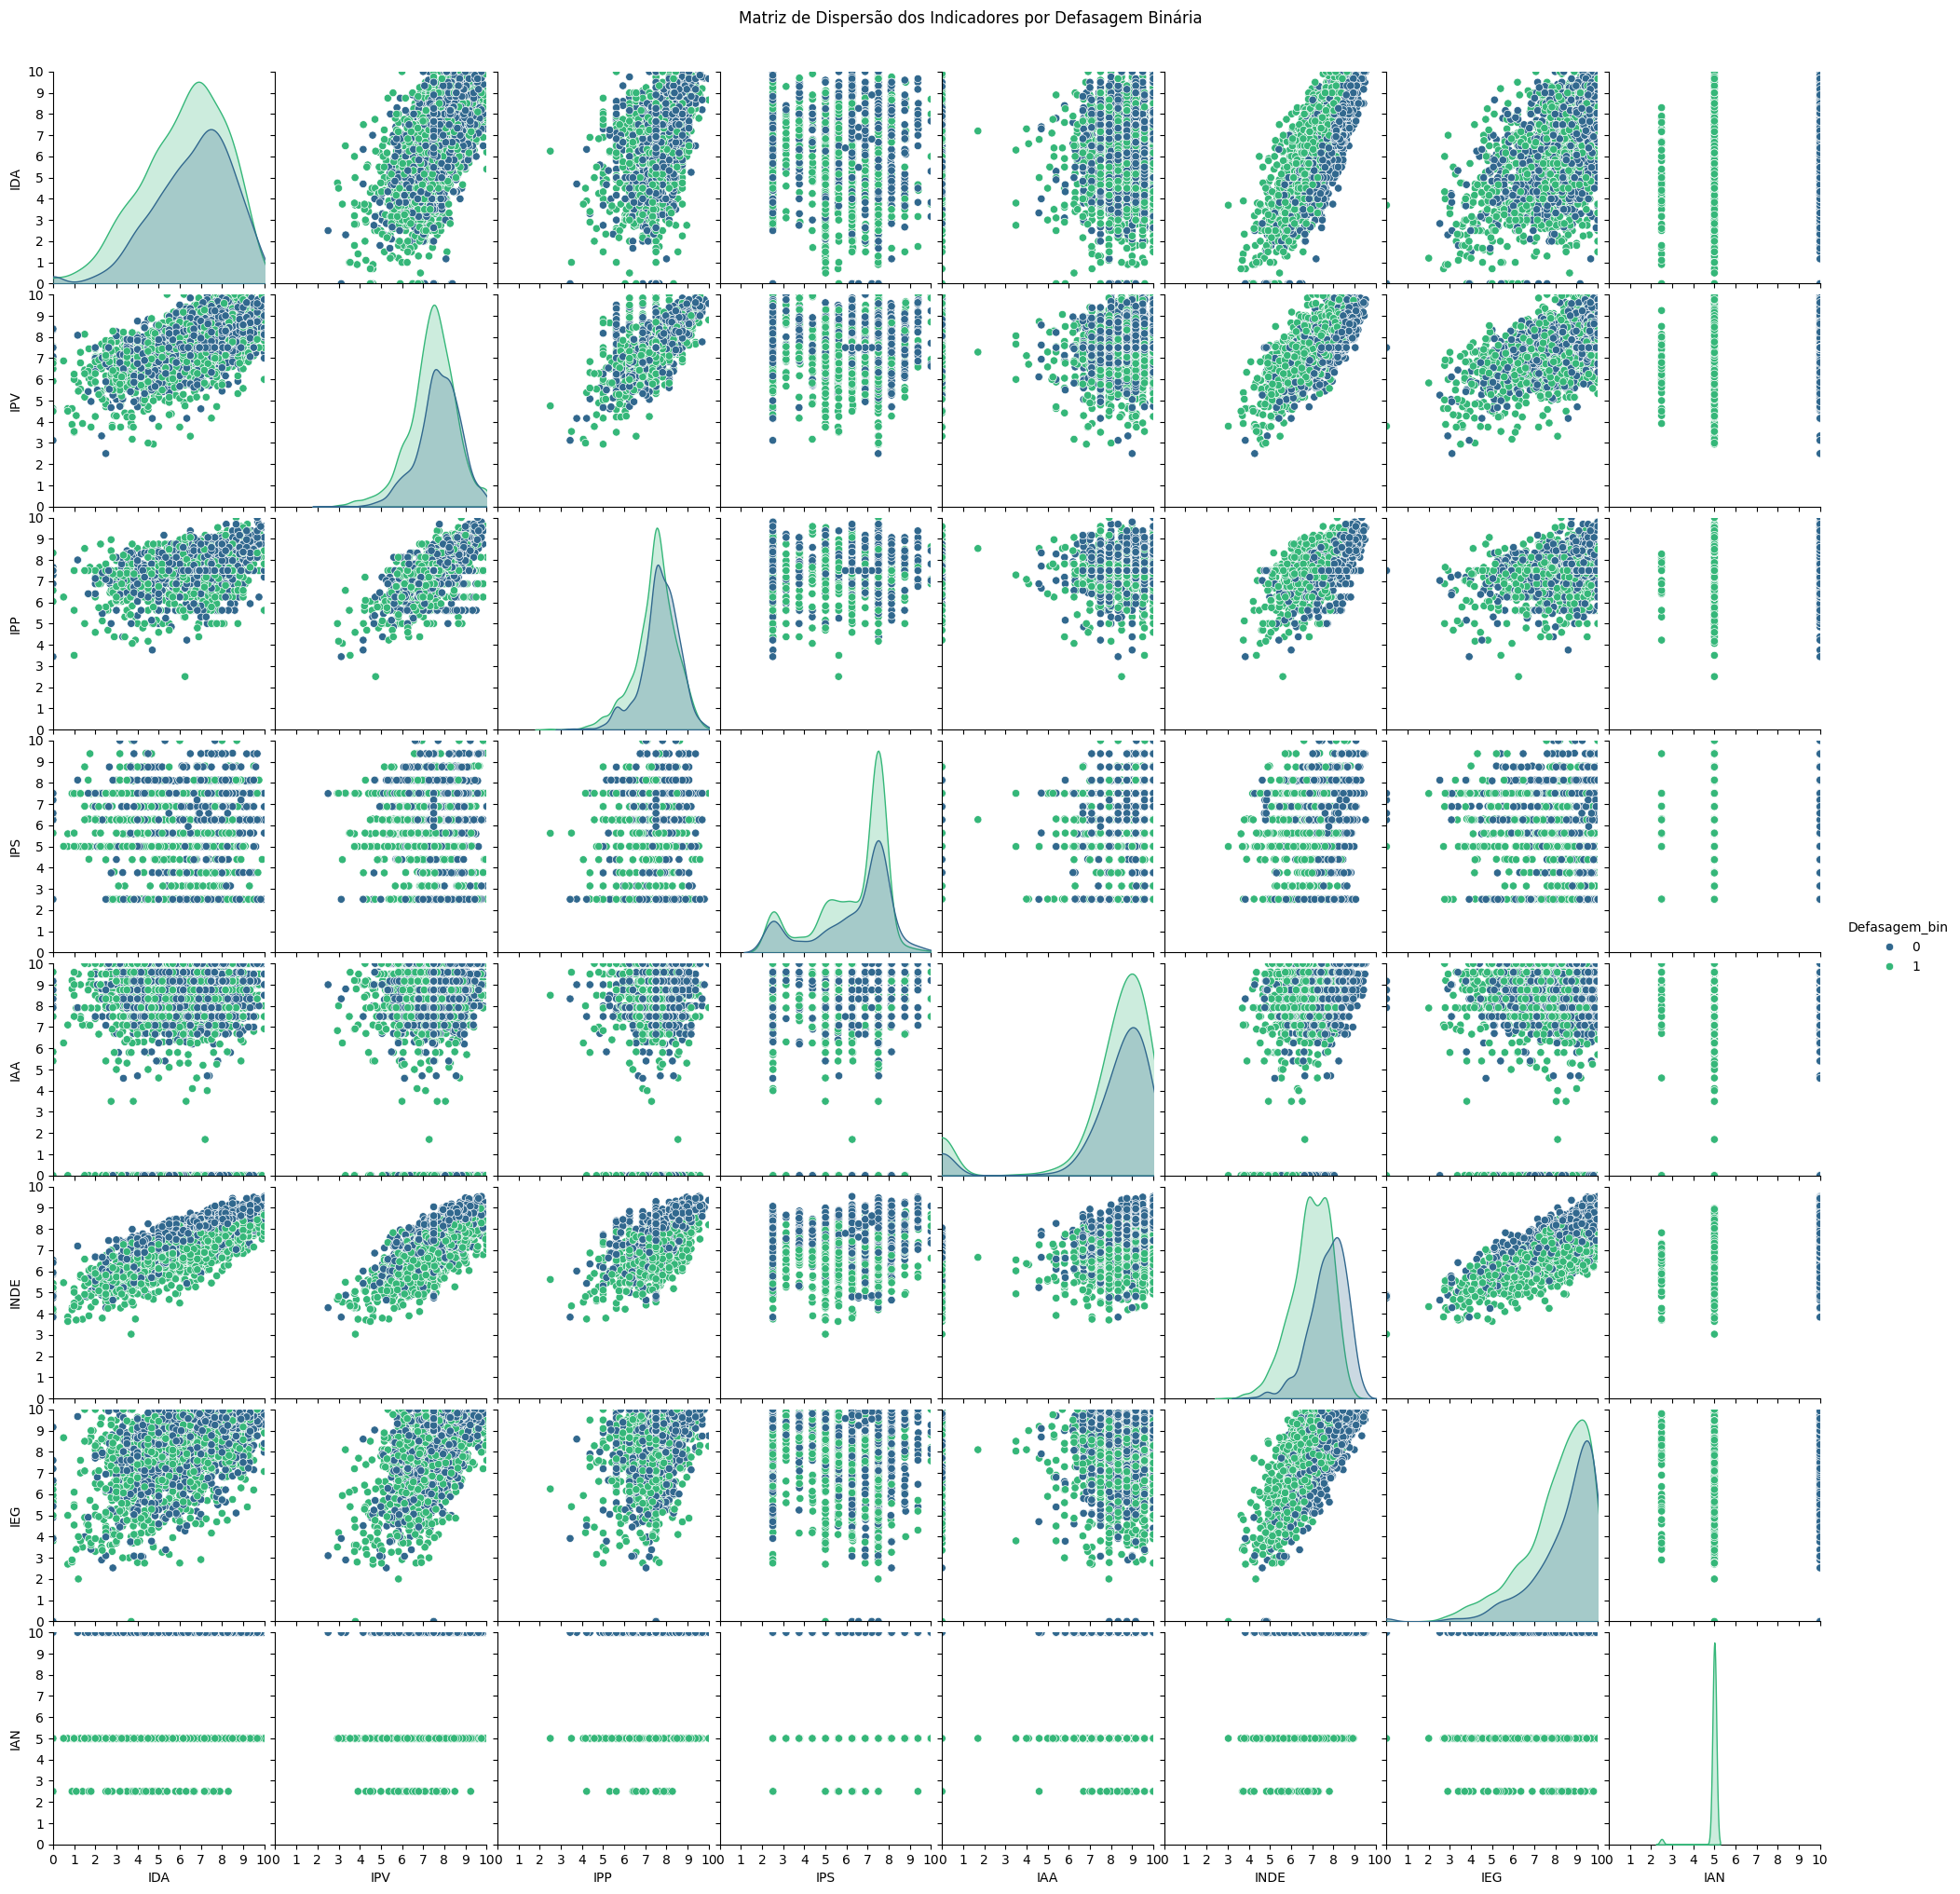

Matriz de dispersão (Pairplot) gerada com sucesso, colorida por 'Defasagem_bin', com eixos padronizados de 0 a 10.


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Certifica de importar numpy

# Identificar colunas numéricas para o pairplot, excluindo 'Defasagem' original
# e incluindo a nova 'Performance_Index'
pairplot_cols = [col for col in df_indicadores_finais.select_dtypes(include=np.number).columns.tolist() if col not in ['Defasagem']]

# Criar o Pairplot, colorindo por 'Defasagem_bin'
g = sns.pairplot(df_indicadores_finais[pairplot_cols], hue='Defasagem_bin', palette='viridis', diag_kind='kde')
plt.suptitle('Matriz de Dispersão dos Indicadores por Defasagem Binária', y=1.02) # Título acima dos subplots

# Padronizar os eixos X e Y para todos os subplots de 0 a 10, de 1 em 1
for ax in g.axes.flat:
    ax.set_xlim(0, 10)
    ax.set_xticks(np.arange(0, 11, 1))
    ax.set_ylim(0, 10)
    ax.set_yticks(np.arange(0, 11, 1))

plt.show()

print("Matriz de dispersão (Pairplot) gerada com sucesso, colorida por 'Defasagem_bin', com eixos padronizados de 0 a 10.")

Estatística Descritiva

In [26]:
print("Estatísticas descritivas para o df_indicadores_finais:")
display(df_indicadores_finais.describe())

Estatísticas descritivas para o df_indicadores_finais:


,IDA,IPV,IPP,IPS,IAA,INDE,IEG,IAN,Defasagem,Defasagem_bin
count,2845.000000,2845.000000,1985.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000
mean,6.376784,7.545910,7.555974,6.297762,7.926578,7.269915,8.229802,7.010545,-0.699473,0.590158
std,1.957528,1.085439,0.938275,1.784413,2.617534,0.991767,1.568487,2.510504,0.849847,0.491891
min,0.000000,2.500000,2.500000,2.500000,0.000000,3.032000,0.000000,2.500000,-5.000000,0.000000
25%,5.100000,6.966000,7.083333,5.020000,7.900000,6.675200,7.500000,5.000000,-1.000000,0.000000
50%,6.666667,7.583000,7.500000,7.500000,8.751000,7.388267,8.654244,5.000000,-1.000000,1.000000
75%,7.833333,8.255000,8.125000,7.510000,9.500000,7.986867,9.400000,10.000000,0.000000,1.000000
max,10.000000,10.010000,10.000000,10.000000,10.002000,9.531325,10.000000,10.000000,3.000000,1.000000


Estatísticas Descritivas para Alunos Não Defasados (Defasagem_bin = 0)

In [27]:
# Filtrando o DataFrame para alunos não defasados (Defasagem_bin == 0)
df_nao_defasados = df_indicadores_finais[df_indicadores_finais['Defasagem_bin'] == 0]

print("Estatísticas descritivas para df_indicadores_finais (Defasagem_bin = 0):")
display(df_nao_defasados.describe())

Estatísticas descritivas para df_indicadores_finais (Defasagem_bin = 0):


,IDA,IPV,IPP,IPS,IAA,INDE,IEG,IAN,Defasagem,Defasagem_bin
count,1166.000000,1166.000000,907.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.0,1166.000000,1166.0
mean,6.625457,7.726608,7.677876,6.307781,8.030273,7.735955,8.455977,10.0,0.142367,0.0
std,1.887917,1.024467,0.891142,1.876344,2.499036,0.876347,1.539063,0.0,0.408459,0.0
min,0.000000,2.500000,3.437500,2.510000,0.000000,3.835478,0.000000,10.0,0.000000,0.0
25%,5.487500,7.210625,7.291667,5.600000,7.917000,7.230520,7.824405,10.0,0.000000,0.0
50%,6.900000,7.792500,7.708333,7.500000,8.751000,7.841816,8.902228,10.0,0.000000,0.0
75%,8.000000,8.416500,8.281250,7.510000,9.500000,8.374331,9.545219,10.0,0.000000,0.0
max,10.000000,10.010000,10.000000,10.000000,10.002000,9.531325,10.000000,10.0,3.000000,0.0


Estatísticas Descritivas para Alunos Defasados (Defasagem_bin = 1)

In [28]:
# Filtrando o DataFrame para alunos defasados (Defasagem_bin == 1)
df_defasados = df_indicadores_finais[df_indicadores_finais['Defasagem_bin'] == 1]

print("Estatísticas descritivas para df_indicadores_finais (Defasagem_bin = 1):")
display(df_defasados.describe())

Estatísticas descritivas para df_indicadores_finais (Defasagem_bin = 1):


,IDA,IPV,IPP,IPS,IAA,INDE,IEG,IAN,Defasagem,Defasagem_bin
count,1679.000000,1679.000000,1078.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.0
mean,6.204090,7.420423,7.453410,6.290804,7.854566,6.946268,8.072732,4.934485,-1.284098,1.0
std,1.986766,1.108941,0.964713,1.718214,2.695153,0.937099,1.569990,0.399488,0.523287,0.0
min,0.000000,2.943333,2.500000,2.500000,0.000000,3.032000,0.000000,2.500000,-5.000000,1.0
25%,4.900000,6.833000,6.875000,5.015000,7.900000,6.394841,7.300000,5.000000,-2.000000,1.0
50%,6.500000,7.500000,7.500000,7.500000,8.751000,7.039000,8.425926,5.000000,-1.000000,1.0
75%,7.750000,8.116667,8.125000,7.510000,9.500000,7.660000,9.300000,5.000000,-1.000000,1.0
max,10.000000,10.010000,10.000000,10.000000,10.002000,8.965000,10.000000,5.000000,-1.000000,1.0


Criando dataframes diferentes para serem utilizados em diferentes situações

In [29]:
# Cria uma cópia temporária do DataFrame original para realizar as operações
temp_df = df_indicadores_finais.copy()

# Atualiza df_indicadores_finais para não conter 'Defasagem_bin'
df_indicadores_finais = temp_df.drop('Defasagem_bin', axis=1, errors='ignore')

# Cria df_indicadores_finais_bin para não conter 'Defasagem'
df_indicadores_finais_bin = temp_df.drop('Defasagem', axis=1, errors='ignore')

print("df_indicadores_finais (sem Defasagem_bin):")
print(df_indicadores_finais.head())
print("\ndf_indicadores_finais_bin (sem Defasagem):")
print(df_indicadores_finais_bin.head())

df_indicadores_finais (sem Defasagem_bin):
   IDA    IPV  IPP  IPS  IAA   INDE  IEG   IAN  Defasagem
0  4.0  7.278  NaN  5.6  8.3  5.783  4.1   5.0         -1
1  6.8  6.778  NaN  6.3  8.8  7.055  5.2  10.0          0
2  5.6  7.556  NaN  5.6  0.0  6.591  7.9  10.0          0
3  5.0  5.278  NaN  5.6  8.8  5.951  4.5  10.0          0
4  5.2  7.389  NaN  5.6  7.9  7.427  8.6  10.0          0

df_indicadores_finais_bin (sem Defasagem):
   IDA    IPV  IPP  IPS  IAA   INDE  IEG   IAN  Defasagem_bin
0  4.0  7.278  NaN  5.6  8.3  5.783  4.1   5.0              1
1  6.8  6.778  NaN  6.3  8.8  7.055  5.2  10.0              0
2  5.6  7.556  NaN  5.6  0.0  6.591  7.9  10.0              0
3  5.0  5.278  NaN  5.6  8.8  5.951  4.5  10.0              0
4  5.2  7.389  NaN  5.6  7.9  7.427  8.6  10.0              0


In [30]:
#Analisando quais indicadores serão mantidos no df final, de acordo com o tipo de informação, se é mais relevante ou não, e de acordo com a quantidade de vazios
df_empilhado_indicadores.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Turma                  3030 non-null   object 
 1   IAN                    3030 non-null   float64
 2   IPS                    2859 non-null   float64
 3   IDA                    2852 non-null   float64
 4   IAA                    2865 non-null   float64
 5   IPP                    2852 non-null   object 
 6   INDE                   2883 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Nome Anonimizado       3030 non-null   str    
 9   Cg                     860 non-null    float64
 10  Gênero                 3030 non-null   str    
 11  Fase                   3030 non-null   object 
 12  RA                     3030 non-null   str    
 13  Instituição de ensino  3029 non-null   str    
 14  Atingiu PV             860 non-null    object 
 15  Pedra          

Removendo as colunas que foram identificadas como não muito relevantes para as visualizações finais gráficas ou que possuem muitos valores nulos

In [31]:
columns_to_drop = ['Cg','RA','Nome Anonimizado','Rec Psicologia','Cf','Destaque IEG','Indicado','Ct','Destaque IPV','Destaque IDA','Atingiu PV']
df_completo_tratado = df_empilhado_indicadores.drop(columns=columns_to_drop)

# Removendo todas as linhas que contenham valores nulos
df_completo_tratado.dropna(inplace=True)

print("Valores nulos removidos do df_completo_tratado com sucesso.")
print(f"O DataFrame resultante possui {df_completo_tratado.shape[0]} linhas e {df_completo_tratado.shape[1]} colunas.")
print("\nVerificação final de valores nulos no df_completo_tratado:")
print(df_completo_tratado.isnull().sum())
df_completo_tratado.info()

Valores nulos removidos do df_completo_tratado com sucesso.
O DataFrame resultante possui 2844 linhas e 16 colunas.

Verificação final de valores nulos no df_completo_tratado:
Turma                    0
IAN                      0
IPS                      0
IDA                      0
IAA                      0
IPP                      0
INDE                     0
Ano ingresso             0
Gênero                   0
Fase                     0
Instituição de ensino    0
Pedra                    0
IPV                      0
Ano                      0
IEG                      0
Defasagem                0
dtype: int64
<class 'pandas.DataFrame'>
Index: 2844 entries, 0 to 2927
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Turma                  2844 non-null   object 
 1   IAN                    2844 non-null   float64
 2   IPS                    2844 non-null   float64
 3   IDA                    

Dataframes finalizados
df_indicadores_finais
Contem os principais indicadores numéricos com a variável target original para utilizar no ML
df_indicadores_finais_bin
Contem os principais indicadores numéricos com a variável target binária (não recomendado para utilizar no ML)
df_completo_tratado
Contém a tabela mais completa com os indicadores que estavam em comum entre as tabelas fornecidas (2022, 2023 e 2024). Considerei somente as colunas que não tinham tanto valor nulo, pois no final eu retirei todos os nulos de todos os dados. Essa base é a ideal para ser utilizada para análise completas de dados e montagem de dashboard.

Machine Learning

Testando Modelo XGBoost

In [32]:
# Separando uma cópia da variável df com as features originais da base de dados para utilizar no modelo
df_xgb = df_indicadores_finais.copy()

from sklearn.preprocessing import LabelEncoder

# Tratando o coluna alvo 'IAN' para que ela fique codificada
le = LabelEncoder()
df_xgb['IAN_encoded'] = le.fit_transform(df_xgb['IAN'])

# Convertendo a coluna alvo do tipo 'object' para XGBoost
X_xgb = df_xgb.drop(['IAN', 'IAN_encoded','Defasagem'], axis=1)

y_xgb = df_xgb['IAN_encoded']

In [34]:
# Separando os grupos de Treino e Teste
from sklearn.model_selection import train_test_split

X_treino_xgb, X_teste_xgb, y_treino_xgb, y_teste_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=45)

#Treinando o modelo utilizando XGBoost
import xgboost as xgb

# Prevendo a probabilidade e definindo o num_class para o número total de classes. (0, 1, 2 = 3 classes)
modelo_xgb = xgb.XGBClassifier(objective='multi:softprob', num_class=3, enable_categorical=True, n_estimators=100, random_state=45)

modelo_xgb.fit(X_treino_xgb, y_treino_xgb)

# Obtendo a classe prevista
preds = modelo_xgb.predict(X_teste_xgb)

In [38]:
#  Prevendo probabilidades para as classes de IAN no conjunto de teste
probabilities = modelo_xgb.predict_proba(X_teste_xgb)

# Exibir as primeiras 5 previsões de probabilidade
print("Primeiras 5 previsões de probabilidade (por classe IAN_encoded):")
print(probabilities[:5])

Primeiras 5 previsões de probabilidade (por classe IAN_encoded):
[[1.8309377e-03 5.4889017e-01 4.4927892e-01]
 [2.1501957e-05 9.8538625e-01 1.4592189e-02]
 [8.7956758e-04 9.9557966e-01 3.5407990e-03]
 [1.4309435e-05 5.3944130e-04 9.9944621e-01]
 [1.6293412e-02 9.6674299e-01 1.6963575e-02]]


In [39]:
# Verificando as métricas MSE e RMSE
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import numpy as np

mse = mean_squared_error(y_teste_xgb, preds)
print(f'MSE: {mse:.2f}')

rmse = mean_squared_error(y_teste_xgb, preds) ** 0.5
print(f'RMSE: {rmse:.2f}')

# Convertendo as previsões contínuas para classes discretas arredondando e convertendo para int
preds_rounded = np.round(preds).astype(int)
preds_treino_rounded = np.round(modelo_xgb.predict(X_treino_xgb)).astype(int) # convertendo a predição de treino

# Verificando a acurácia usando as previsões arredondadas
acc_treino = accuracy_score(y_treino_xgb, preds_treino_rounded)
acc_teste = accuracy_score(y_teste_xgb, preds_rounded)

print(f"Acurácia no conjunto de treino (XGBoost): {acc_treino:.2%}")
print(f"Acurácia no conjunto de teste (XGBoost): {acc_teste:.2%}")

# Exibir um relatório de classificação para obter métricas mais detalhadas
print("\nRelatório de Classificação:")
print(classification_report(y_teste_xgb, preds_rounded))

MSE: 0.06
RMSE: 0.24
Acurácia no conjunto de treino (XGBoost): 100.00%
Acurácia no conjunto de teste (XGBoost): 94.02%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.92      0.99      0.95       339
           2       0.99      0.91      0.95       222

    accuracy                           0.94       569
   macro avg       0.64      0.63      0.63       569
weighted avg       0.93      0.94      0.94       569



Testando Modelo CatBoost

In [49]:
import catboost
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report

# Criando um objeto Pool para o CatBoost
# Como não temos colunas categóricas no X_xgb, não precisamos especificar cat_features
train_pool = Pool(X_treino_xgb, y_treino_xgb)
test_pool = Pool(X_teste_xgb, y_teste_xgb)

# Inicializando o modelo CatBoostClassifier
# Usando um objetivo similar ao multi:softprob do XGBoost, que é MultiClass para CatBoost
# random_seed para reprodutibilidade
# verbose=0 para não imprimir o log de treinamento
# iterations (n_estimators) para o número de árvores
modelo_catboost = CatBoostClassifier(
    objective='MultiClass',
    iterations=100, # Similar ao n_estimators do XGBoost
    random_seed=45,
    verbose=0,
    learning_rate=0.1
)

# Treinando o modelo CatBoost
modelo_catboost.fit(train_pool)

# Fazendo previsões no conjunto de teste
preds_catboost = modelo_catboost.predict(X_teste_xgb)

# Convertendo as previsões para classes inteiras, se necessário
preds_catboost_flattened = preds_catboost.flatten()

In [50]:
# Avaliando a acurácia
acc_catboost = accuracy_score(y_teste_xgb, preds_catboost_flattened)
print(f"Acurácia do CatBoost no conjunto de teste: {acc_catboost:.2%}")

# Exibindo o relatório de classificação
print("\nRelatório de Classificação (CatBoost):")
print(classification_report(y_teste_xgb, preds_catboost_flattened))

Acurácia do CatBoost no conjunto de teste: 91.74%

Relatório de Classificação (CatBoost):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.89      0.99      0.93       339
           2       0.97      0.85      0.91       222

    accuracy                           0.92       569
   macro avg       0.62      0.61      0.61       569
weighted avg       0.91      0.92      0.91       569



c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in lab

Técnica muito utilizada, principalmente em variáveis categóricas. Entretanto sua acurácia neste conjunto de dados foi menor que a da técnica de XGBoost.

In [139]:
import pandas as pd

# Se ainda não existir, criar o alvo risco a partir da defasagem (Defas)
df["risco"] = df["Defas"].apply(lambda x: 0 if x <= -1 else (1 if x == 0 else 2))

print("Distribuição de classes (contagem):")
print(df["risco"].value_counts().sort_index())

print("\nDistribuição de classes (percentual):")
print((df["risco"].value_counts(normalize=True).sort_index() * 100).round(2))

# Checagem simples: médias dos indicadores por classe
features = ["IAN","IDA","IEG","IAA","IPS","IPV"]
print("\nMédia dos indicadores por classe:")
print(df.groupby("risco")[features].mean().round(2))

Distribuição de classes (contagem):
risco
0    601
1    247
2     12
Name: count, dtype: int64

Distribuição de classes (percentual):
risco
0    69.88
1    28.72
2     1.40
Name: proportion, dtype: float64

Média dos indicadores por classe:
         IAN   IDA   IEG   IAA   IPS   IPV
risco                                     
0       4.88  5.93  7.74  8.22  6.89  7.19
1      10.00  6.43  8.20  8.39  6.94  7.37
2      10.00  7.28  9.20  8.59  6.88  8.01


Testando Modelo Regressão Logística

In [154]:
df["risco"] = df["Defas"].apply(
    lambda x: 0 if x <= -1 else (1 if x == 0 else 2)
)

In [ ]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# target (mantenha a regra que você já está usando)
df["risco"] = df["Defas"].apply(lambda x: 0 if x <= -1 else (1 if x == 0 else 2))

features = ["IAN","IDA","IEG","IAA","IPS","IPV"]

X = df[features].copy()
y = df["risco"]

X = 10 - X

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs"))
])

modelo.fit(X_train, y_train)
preds = modelo.predict(X_test)

bundle = {
    "model": modelo,
    "features": features,
    "class_names": {
        0: "Baixo risco educacional",
        1: "Risco moderado de defasagem",
        2: "Alto risco de defasagem educacional"
    },
    "invert_scale_0_10": True 
}

joblib.dump(
    bundle,
    r"C:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\DATATHON\modelo_treinado.pkl"
)

print("✅ Salvo.")

✅ Salvo.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error
)

# -------------------------------------------------
# Previsões
# -------------------------------------------------

# Previsões no conjunto de teste
preds_teste = modelo.predict(X_test)

# Previsões no conjunto de treino
preds_treino = modelo.predict(X_train)

# -------------------------------------------------
# Métricas
# -------------------------------------------------

mse = mean_squared_error(y_test, preds_teste)
print(f"MSE: {mse:.2f}")

rmse = mean_squared_error(y_test, preds_teste) ** 0.5
print(f"RMSE: {rmse:.2f}")

# -------------------------------------------------
# Acurácia
# -------------------------------------------------

acc_teste = accuracy_score(y_test, preds_teste)
acc_treino = accuracy_score(y_train, preds_treino)

print(f"Acurácia da Regressão Logística no conjunto de treino: {acc_treino:.2%}")
print(f"Acurácia da Regressão Logística no conjunto de teste: {acc_teste:.2%}")

# -------------------------------------------------
# Relatório de Classificação
# -------------------------------------------------

print("\nRelatório de Classificação (Regressão Logística):")
print(classification_report(y_test, preds_teste))

MSE: 0.01
RMSE: 0.11
Acurácia da Regressão Logística no conjunto de treino: 98.55%
Acurácia da Regressão Logística no conjunto de teste: 98.84%

Relatório de Classificação (Regressão Logística):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       0.96      1.00      0.98        50
           2       0.00      0.00      0.00         2

    accuracy                           0.99       172
   macro avg       0.65      0.67      0.66       172
weighted avg       0.98      0.99      0.98       172



c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NicollyPaivaHeinzl\Desktop\FIAP\1 - Data Analysis and Exploration\Códigos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in lab

Por mais que pareça um modelo mais simples, principalmente comparado com XGBoost, a Regressão Logística é indicada para Volume de Dados de pequeno a médio tamanho, como é o caso desta base de dados. Ela demonstrou melhor desempenho, chegando a uma acurácia de 98.84%

Insights utilizando o modelo de ML com maior acurácia alcançada (Regressão Logística)

C:\Users\NicollyPaivaHeinzl\AppData\Local\Temp\ipykernel_30392\2495581583.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


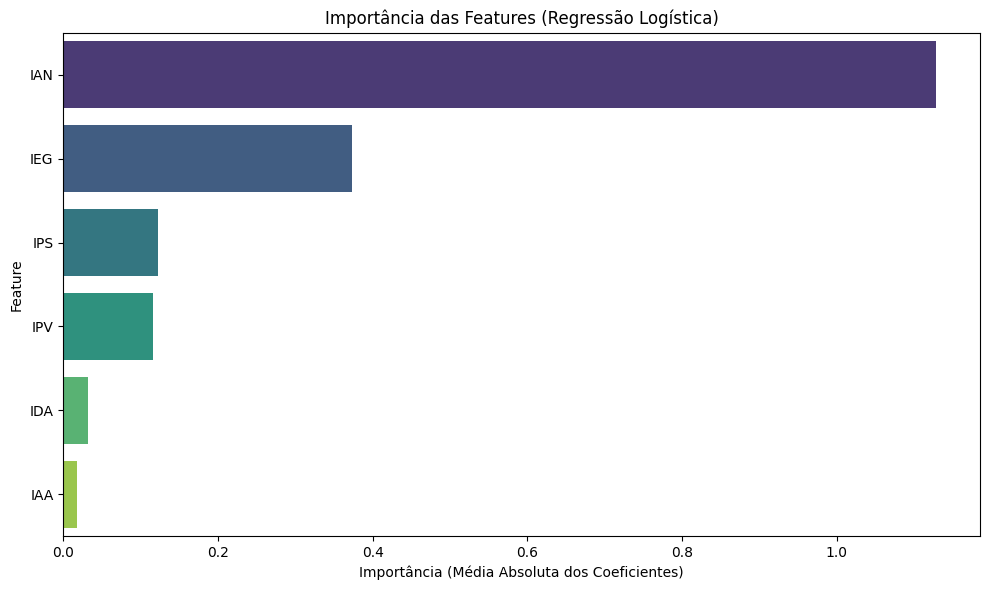

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# Importância das Features (Regressão Logística)
# -------------------------------------------------

feature_importances = pd.DataFrame({
    "Feature": features,  
    "Importance": np.mean(np.abs(modelo.coef_), axis=0)
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importances,
    palette="viridis"
)

plt.title("Importância das Features (Regressão Logística)")
plt.xlabel("Importância (Média Absoluta dos Coeficientes)")
plt.ylabel("Feature")
plt.grid(False)
plt.tight_layout()
plt.show()

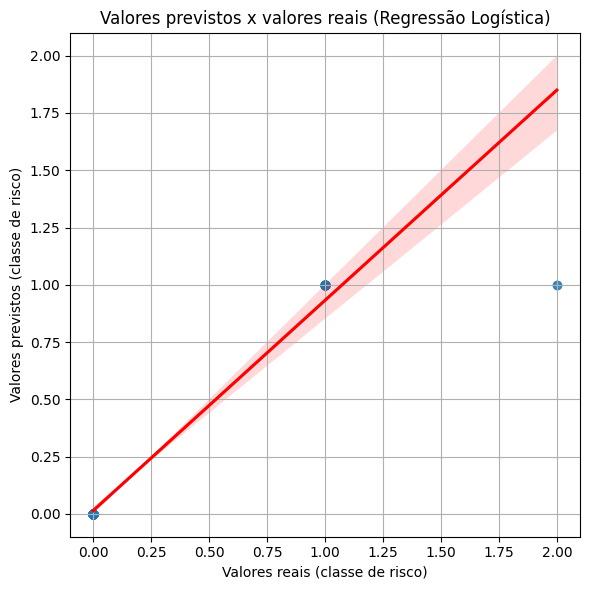

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.regplot(
    x=y_test,
    y=preds_teste,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.xlabel("Valores reais (classe de risco)")
plt.ylabel("Valores previstos (classe de risco)")
plt.title("Valores previstos x valores reais (Regressão Logística)")
plt.grid(True)
plt.tight_layout()
plt.show()

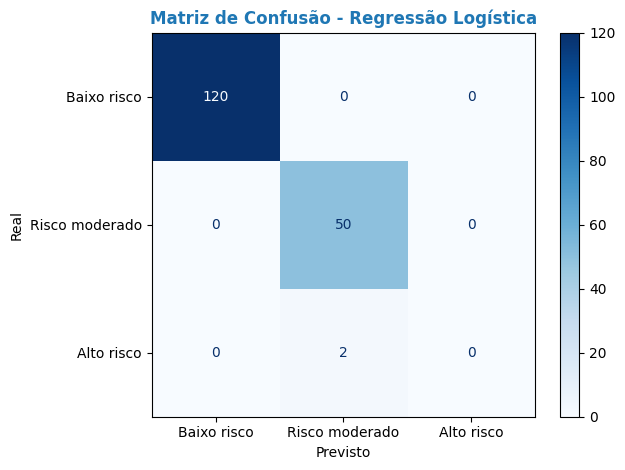

In [173]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------------------------------------------------
# Matriz de Confusão - Regressão Logística
# -------------------------------------------------

# Calcula a matriz de confusão com valores reais e previstos
conf_matrix = confusion_matrix(y_test, preds_teste)

# Cria o display da matriz de confusão
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["Baixo risco", "Risco moderado", "Alto risco"]
)

# Plot
disp.plot(cmap="Blues", values_format="d")
plt.title(
    "Matriz de Confusão - Regressão Logística",
    color="tab:blue",
    weight="bold"
)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()